### Métodos de imputación multivariada

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def graficar_serie(df, obs = '', titulo=''):
    '''
    Graficar la serie y ver sus valores extremos
    Params:
        - df    : DataFrame de Pandas con la serie de tiempo
        - obs   : Nombre de la columna a graficar
        - titulo: Título del gráfico
    '''

    fig, ax = plt.subplots(1, 1)

    if type(df) == pd.DataFrame:
        ax = sns.pointplot(data = df, x = df.index, y = obs, markers='')
    else:
        df = df.to_frame(name = obs)
        ax = sns.pointplot(data = df, x = df.index, y = obs, markers='')
    
    n_ticks = 10
    locator = mdates.AutoDateLocator(maxticks = n_ticks)
    ax.xaxis.set_major_locator(locator)

    plt.xticks(rotation = 45)
    
    ax.set_xlabel('Tiempo')
    ax.set_ylabel(obs)
    ax.set_title(titulo)  

/tmp/ipykernel_168027/3784476571.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clicks_df = pd.read_csv('datos/clicks_obs_faltantes.csv',


               precio  ubicacion   clicks
fecha                                    
2008-04-01  43.155647          2  18784.0
2008-04-02  43.079056          1  24738.0
2008-04-03  43.842609          2  15209.0
2008-04-04  43.312376          1  14018.0
2008-04-05  43.941176          1  11974.0


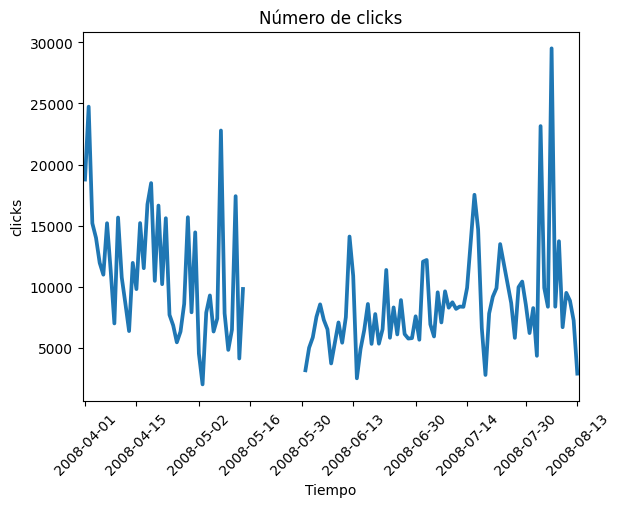

In [40]:
clicks_df = pd.read_csv('datos/clicks_obs_faltantes.csv',
                        parse_dates=['fecha'],
                        index_col='fecha')
clicks_df = clicks_df.rename(columns={'ubicación' : 'ubicacion'})
print(clicks_df.head())
graficar_serie(clicks_df, obs = 'clicks', titulo = 'Número de clicks')

### Imputación con modelos de Regresión con ***Iterative Imputer***

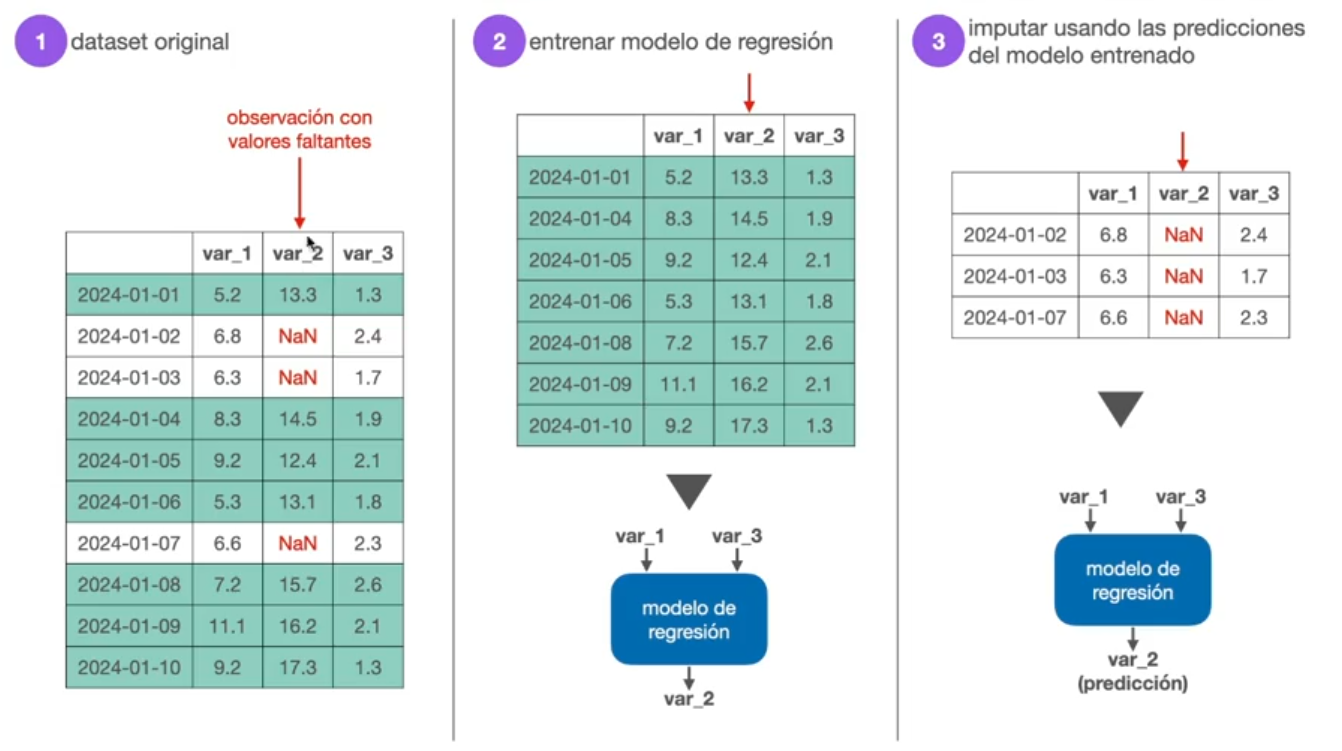

In [41]:
clicks_df.head()

,precio,ubicacion,clicks
fecha,,,
2008-04-01,43.155647,2,18784.0
2008-04-02,43.079056,1,24738.0
2008-04-03,43.842609,2,15209.0
2008-04-04,43.312376,1,14018.0
2008-04-05,43.941176,1,11974.0


In [42]:
datos = clicks_df.to_numpy()
clicks_df.isna().sum()

precio        0
ubicacion     0
clicks       16
dtype: int64

In [43]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

it_imputer = IterativeImputer(estimator=LinearRegression())
it_imputer.fit(datos)

,"estimator estimator: estimator object, default=BayesianRidge()The estimator to use at each step of the round-robin imputation.If `sample_posterior=True`, the estimator must support`return_std` in its `predict` method.",LinearRegression()
,"missing_values missing_values: int or np.nan, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"sample_posterior sample_posterior: bool, default=FalseWhether to sample from the (Gaussian) predictive posterior of thefitted estimator for each imputation. Estimator must support`return_std` in its `predict` method if set to `True`. Set to`True` if using `IterativeImputer` for multiple imputations.",False
,"max_iter max_iter: int, default=10Maximum number of imputation rounds to perform before returning theimputations computed during the final round. A round is a singleimputation of each feature with missing values. The stopping criterionis met once `max(abs(X_t - X_{t-1}))/max(abs(X[known_vals])) < tol`,where `X_t` is `X` at iteration `t`. Note that early stopping is onlyapplied if `sample_posterior=False`.",10
,"tol tol: float, default=1e-3Tolerance of the stopping condition.",0.001
,"n_nearest_features n_nearest_features: int, default=NoneNumber of other features to use to estimate the missing values ofeach feature column. Nearness between features is measured usingthe absolute correlation coefficient between each feature pair (afterinitial imputation). To ensure coverage of features throughout theimputation process, the neighbor features are not necessarily nearest,but are drawn with probability proportional to correlation for eachimputed target feature. Can provide significant speed-up when thenumber of features is huge. If `None`, all features will be used.",None
,"initial_strategy initial_strategy: {'mean', 'median', 'most_frequent', 'constant'}, default='mean'Which strategy to use to initialize the missing values. Same as the`strategy` parameter in :class:`~sklearn.impute.SimpleImputer`.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen `strategy=""constant""`, `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types... versionadded:: 1.3",None
,"imputation_order imputation_order: {'ascending', 'descending', 'roman', 'arabic', 'random'}, default='ascending'The order in which the features will be imputed. Possible values:- `'ascending'`: From features with fewest missing values to most.- `'descending'`: From features with most missing values to fewest.- `'roman'`: Left to right.- `'arabic'`: Right to left.- `'random'`: A random order for each round.",'ascending'
,"skip_complete skip_complete: bool, default=FalseIf `True` then features with missing values during :meth:`transform`which did not have any missing values during :meth:`fit` will beimputed with the initial imputation method only. Set to `True` if youhave many features with no missing values at both :meth:`fit` and:meth:`transform` time to save compute.",False
,"min_value min_value: float or array-like of shape (n_features,), default=-np.infMinimum possible imputed value. Broadcast to shape `(n_features,)` ifscalar. If array-like, expects shape `(n_features,)`, one min value foreach feature. The default is `-np.inf`... versionchanged:: 0.23 Added support for array-like.",-inf


In [44]:
clicks_df['clicks_imp'] = it_imputer.transform(datos)[:,2]
clicks_df

,precio,ubicacion,clicks,clicks_imp
fecha,,,,
2008-04-01,43.155647,2,18784.0,18784.0
2008-04-02,43.079056,1,24738.0,24738.0
2008-04-03,43.842609,2,15209.0,15209.0
2008-04-04,43.312376,1,14018.0,14018.0
2008-04-05,43.941176,1,11974.0,11974.0
...,...,...,...,...
2008-08-09,44.182033,1,6716.0,6716.0
2008-08-10,43.608260,1,9523.0,9523.0
2008-08-11,43.553363,1,8881.0,8881.0


In [45]:
clicks_df.isna().sum()

precio         0
ubicacion      0
clicks        16
clicks_imp     0
dtype: int64

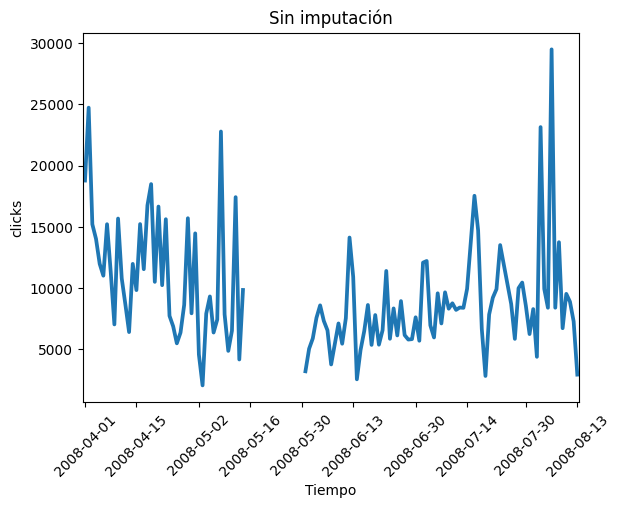

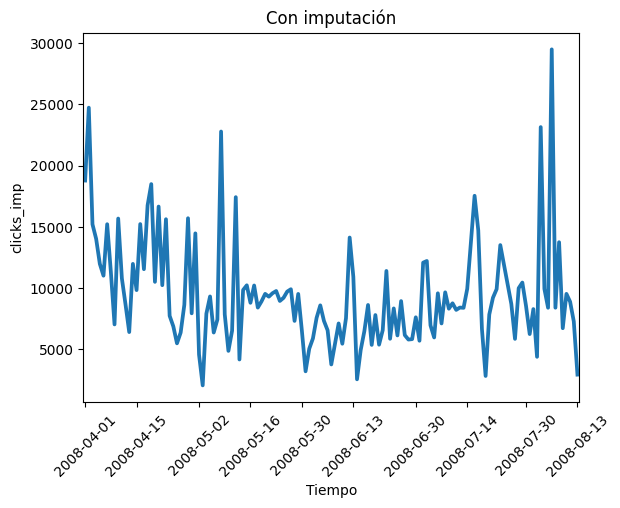

In [46]:
graficar_serie(clicks_df, obs = 'clicks', titulo = 'Sin imputación')
graficar_serie(clicks_df, obs = 'clicks_imp', titulo = 'Con imputación')


### Imputación con el algoritmo MICE (Multiple Imputation by Chained Ecuations)

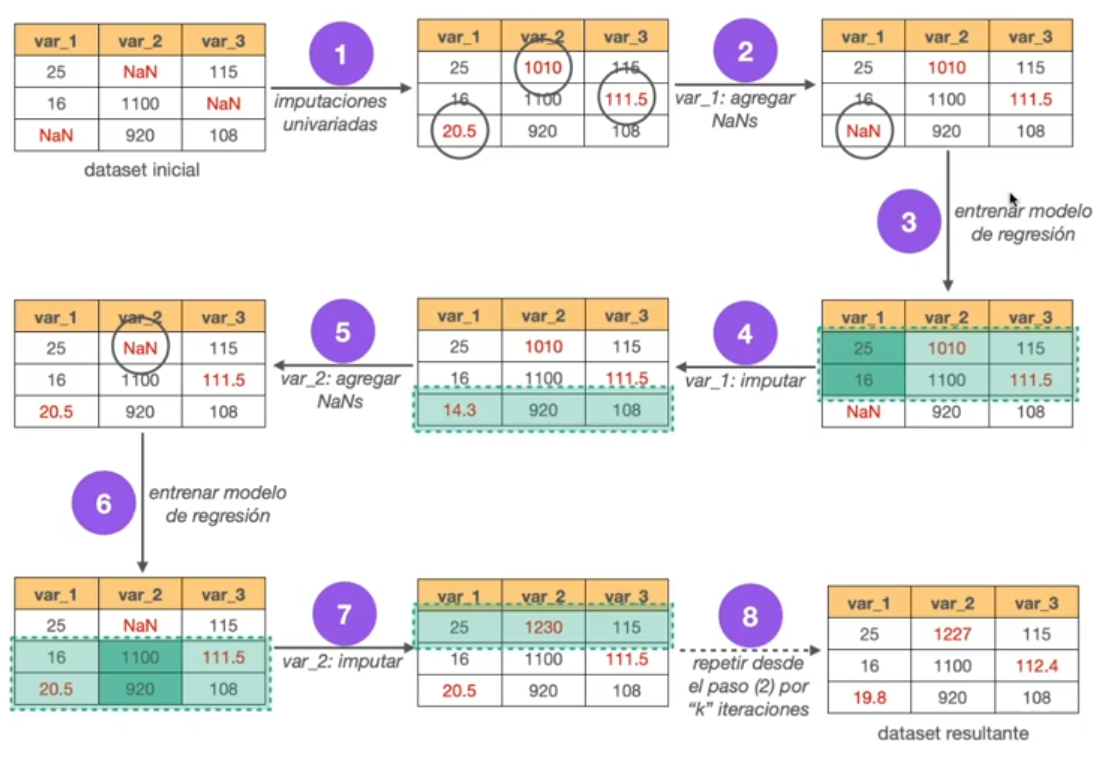

In [47]:
from statsmodels.imputation.mice import MICEData
import statsmodels.api as sm

mice_data = MICEData(clicks_df)
mice_data.data

,precio,ubicacion,clicks,clicks_imp
0,43.155647,2,18784.0,18784.0
1,43.079056,1,24738.0,24738.0
2,43.842609,2,15209.0,15209.0
3,43.312376,1,14018.0,14018.0
4,43.941176,1,11974.0,11974.0
...,...,...,...,...
130,44.182033,1,6716.0,6716.0
131,43.608260,1,9523.0,9523.0
132,43.553363,1,8881.0,8881.0
133,44.500469,1,7272.0,7272.0


In [49]:
mice_data.set_imputer('clicks', formula = 'precio + ubicacion', model_class = sm.OLS)
mice_data.update_all(n_iter = 10)

In [50]:
mice_data.data.isna().sum()

precio        0
ubicacion     0
clicks        0
clicks_imp    0
dtype: int64

In [56]:
clicks_df['MICE'] = mice_data.data['clicks'].to_numpy()

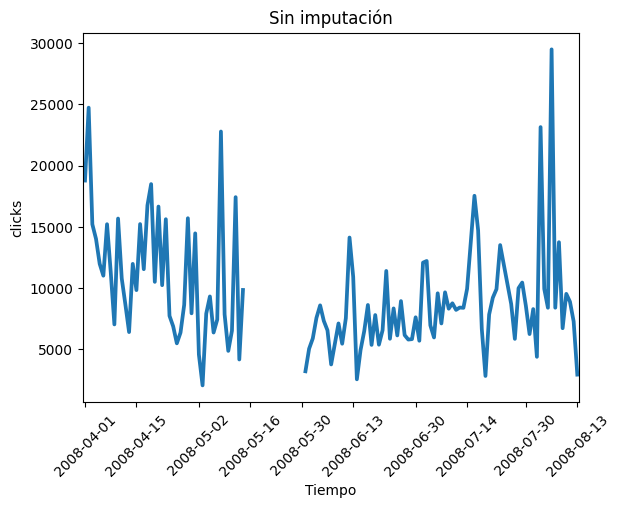

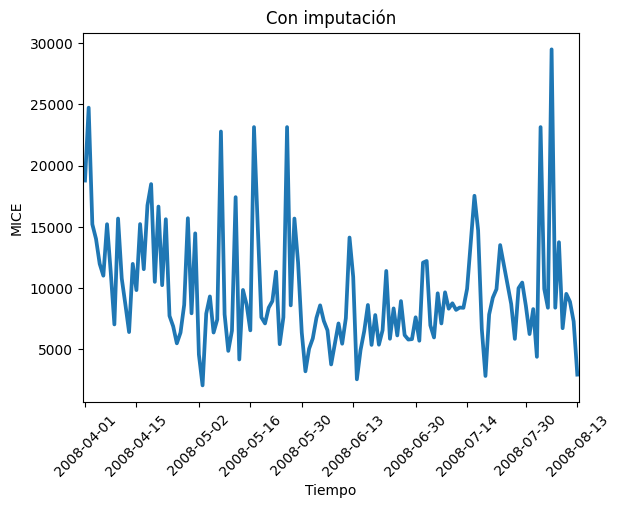

In [57]:
graficar_serie(clicks_df, obs = 'clicks', titulo = 'Sin imputación')
graficar_serie(clicks_df, obs = 'MICE', titulo = 'Con imputación')